In [36]:
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from tqdm.auto import trange

#DEVICE = "cpu"
DEVICE = "mps"
torch.manual_seed(1337)

SHAKESPEAR = open("shakespeare.txt", "r").read()
VOCAB = list(sorted(set(SHAKESPEAR)))
CHAR_MAP = {c:i for i,c in enumerate(VOCAB)}

def encode(s):
    return torch.tensor([CHAR_MAP[c] for c in s])

def decode(l):
    return ''.join([VOCAB[i] for i in l])

SHAKESPEAR_ENCODED = encode(SHAKESPEAR).to(DEVICE)

INPUT_TRAIN = SHAKESPEAR_ENCODED[0:int(len(SHAKESPEAR_ENCODED)*0.9)]
INPUT_TEST = SHAKESPEAR_ENCODED[int(len(SHAKESPEAR_ENCODED)*0.9):]

def get_batch(input_set, batch_size, block_size=8):
    ix = torch.randint(len(input_set) - block_size, (batch_size,), device=input_set.device)
    offsets = torch.arange(block_size, device=input_set.device)
    indices = ix[:, None] + offsets
    return input_set[indices], input_set[indices+1]

@torch.no_grad()
def estimate_loss(model, iterations=10, batch_size=32, block_size=8):
    model.eval()
    losses_train = torch.stack(
        [model(*get_batch(INPUT_TRAIN, batch_size, block_size)) for _ in range(iterations)]
    )
    losses_test = torch.stack(
        [model(*get_batch(INPUT_TEST, batch_size, block_size)) for _ in range(iterations)]
    )
    model.train()
    return (losses_train.mean(), losses_test.mean())

class BiCharModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, context_width, inner_layer, inner_layer2=None):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.context_width = context_width
        self.inner_layer = inner_layer
        self.inner_layer2 = inner_layer2
        self.embedding = nn.Embedding(vocab_size, embedding_dim, device=DEVICE)
        self.linear1 = nn.Linear(embedding_dim * context_width, inner_layer, device=DEVICE)
        self.activation1 = nn.Tanh()
        self.linear2 = nn.Linear(inner_layer, vocab_size if inner_layer2 is None else inner_layer2, bias=(inner_layer2 is not None), device=DEVICE)
        if inner_layer2 is not None:
            self.activation2 = nn.Tanh()
            self.linear3 = nn.Linear(inner_layer2, vocab_size, bias=False, device=DEVICE)

    def forward(self, X, Y=None):
        x = self.embedding(X)
        x = x.view(X.shape[0], -1)
        x = self.linear1(x)
        x = self.activation1(x)
        x = self.linear2(x)
        if self.inner_layer2 is not None:
            x = self.activation2(x)
            x = self.linear3(x)
        if Y is not None:
            loss = F.cross_entropy(x, Y[..., -1:].view(-1))
            return loss
        else:
            return x

    def generate(self, context, max_new_tokens):
        for _ in range(max_new_tokens):
            probs, loss = self(context[...,-self.context_width:])
            probs = probs.softmax(dim=1)
            context = torch.cat((context, torch.multinomial(probs, num_samples=1)), dim=1)
        return context

# loss_test=1.9145, loss_tr=1.7595
#m = BiCharModel(len(VOCAB), 32, 8, 200).to(DEVICE)
# loss_test=1.8474, loss_tr=1.6586
#m = BiCharModel(len(VOCAB), 32, 16, 200, 128).to(DEVICE)
# loss_test=1.8272, loss_tr=1.6379
m = BiCharModel(len(VOCAB), 32, 32, 200, 128).to(DEVICE)

stats_losses = []
def training_loop(model, optimizer, input_set, iterations, batch_size = 32, block_size = 1):
    progress = trange(iterations, desc="Training")
    for i in progress:
        X, Y = get_batch(input_set, batch_size, block_size)
        loss = model(X, Y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if i%100 == 0:
            losses = estimate_loss(model, 100, batch_size, block_size)
            progress.set_postfix(
                loss_tr=f"{losses[0]:.4f}",
                loss_test=f"{losses[1]:.4f}",
            )
            stats_losses.append(losses)
    return estimate_loss(model, 100, batch_size, block_size)

total = sum(p.numel() for p in m.parameters())
print(f"Parameters: {total:,}")

optimizer = optim.AdamW(m.parameters(), lr=1e-3)
training_loop(m, optimizer, INPUT_TRAIN, 100, 64, 32)

#X, Y = get_batch(INPUT_TRAIN, 2, 1)
#m(X, Y)[1]



Parameters: 241,128


Training: 100%|██████████| 100/100 [00:00<00:00, 684.62it/s, loss_test=4.0904, loss_tr=4.0908]


(tensor(2.9629, device='mps:0'), tensor(2.9803, device='mps:0'))

Training: 100%|██████████| 5000/5000 [00:18<00:00, 265.64it/s, loss_test=1.8272, loss_tr=1.6379]


(1.614184275865555, 1.863981418609619)


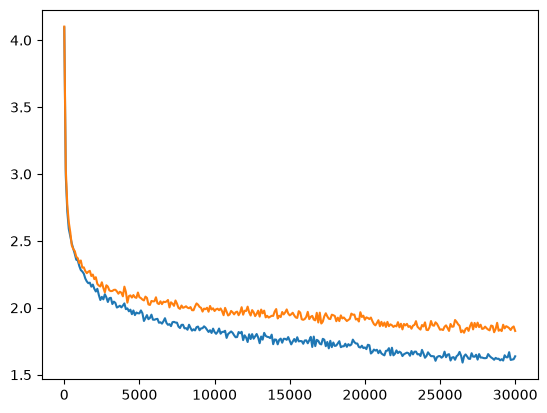

In [151]:
import matplotlib.pyplot as plt

optimizer = optim.AdamW(m.parameters(), lr=1e-4)
print(training_loop(m, optimizer, INPUT_TRAIN, 5000, 64, 32))

plt.plot([x*100 for x in range(len(stats_losses))], [y[0] for y in stats_losses])
plt.plot([x*100 for x in range(len(stats_losses))], [y[1] for y in stats_losses])

In [152]:
CONTEXT_WIDTH = 32
print(''.join([VOCAB[i] for i in m.generate(torch.zeros((1, CONTEXT_WIDTH), dtype=torch.long, device=DEVICE), 1000)[0][CONTEXT_WIDTH:].tolist()]))

lIN LO:l: Ifre, this profort I am, thee and madiers,
How that, thee that misuland the beath,
And of your sonet.

Cloch my tell.

DUKE VINCENTIO:

Comisdown wur--blation tell friend,
I have sir;
Her fois thuse rouns is the forthes.
As land at no ere more
The strish wiolien's my roneofs,
This boother?
A stis be what shall the worge seep appily's with upcely, and
booth
Rome: cename both of from the pootly unforthes, bey brother batigiter
We, my gityreest to of the shall we sughter.

CLASTIAGLADUMBIINA:
Thy Widroment,
I cinsn'm meless cattion,:
I grieve yed fause please, What notit secome an me wart,
Hebpes I am corse their,
He: some payss not us him needs with
By sever fast thus his should friess? Larreed
And yerporse her bracking conse it
a lo'th berough bal this usbrains, crowned's that metter.

GLOUCESTER:
He paymes to pall be netenved, sound how sears out in wen forentiugs,
What him sie so; by son, and proin as groqnong.

VOLUMETOLAUD:
Bas make you. I lest?
Sim,'n: and prieaty our dro

In [153]:
a = torch.tril(torch.ones(8, 8))
print(a)
b = torch.randn(8, 8)
print(b)
b = torch.masked_fill(b, a == 0.0, float('-inf'))
print(b)
print(F.softmax(b, dim=1))


tensor([[1., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1.]])
tensor([[ 0.6634,  0.2900,  0.7281,  1.7852, -0.3800,  0.3160,  2.4203,  0.2652],
        [-0.1817,  0.4126, -0.9716, -1.2573,  0.7382, -0.9881, -0.6718,  1.1819],
        [ 0.2934, -1.6472,  1.5110, -0.4663, -0.4951,  2.1344, -0.4869, -0.1756],
        [ 0.5817,  1.4942,  1.7635, -1.0484,  0.0876,  0.6153, -0.0992, -0.4275],
        [-2.0165,  0.7787, -1.3606,  1.4223, -0.7355, -0.4665,  1.1841,  1.5241],
        [ 0.8168, -0.2348, -0.1606,  0.4396,  0.8118, -1.9570,  0.0952, -0.1679],
        [ 0.5141,  0.8152,  0.0630, -0.2152, -0.3988,  0.6990, -1.3037,  2.2775],
        [-1.0539, -0.6243, -0.6557, -1.7494, -1.6957,  0.4719,  0.4539,  0.5682]])
tensor

In [ ]:
import math

class AttentionHead(nn.Module):
    def __init__(self, context_width, embedding_size, head_size):
        super().__init__()
        self.head_size = head_size
        self.key = nn.Linear(embedding_size, head_size, bias=False, device=DEVICE)
        self.query = nn.Linear(embedding_size, head_size, bias=False, device=DEVICE)
        self.value = nn.Linear(embedding_size, head_size, bias=False, device=DEVICE)
        self.proj = nn.Linear(head_size, head_size, bias=False, device=DEVICE)
        self.register_buffer('tril', torch.tril(torch.ones(context_width, context_width)))
    
    def forward(self, x): 
        k = self.key(x)
        q = self.query(x)
        out = q @ k.transpose(-2, -1)
        out = out / math.sqrt(self.head_size)
        out = out.masked_fill(self.tril[:x.shape[-2],:x.shape[-2]]==0, float('-inf'))
        out = F.softmax(out, dim=-1)
        v = self.value(x)
        return self.proj(out @ v)

class MultiHeadAttention(nn.Module):
    def __init__(self, context_width, embedding_size, head_size, num_heads):
        super().__init__()
        self.heads = nn.ModuleList([AttentionHead(context_width, embedding_size, head_size) for _ in range(num_heads)])
    
    def forward(self, x):
        return torch.cat([head(x) for head in self.heads], dim=-1)

class FeedForward(nn.Module):
    def __init__(self, embedding_size):
        super().__init__()
        self.linear1 = nn.Linear(embedding_size, embedding_size*4, device=DEVICE)
        self.activation = nn.ReLU()
        self.linear2 = nn.Linear(embedding_size*4, embedding_size, device=DEVICE)
    
    def forward(self, x):
        x = self.linear1(x)
        x = self.activation(x)
        x = self.linear2(x)
        return x

class AttentionBlock(nn.Module):
    def __init__(self, context_width, embedding_size, num_heads):
        super().__init__()
        assert embedding_size % num_heads == 0, "embedding_size must be divisible by num_heads"
        self.head_size = embedding_size // num_heads
        self.ln1 = nn.LayerNorm(embedding_size, device=DEVICE)
        self.mha = MultiHeadAttention(context_width, embedding_size, self.head_size, num_heads)
        self.ln2 = nn.LayerNorm(embedding_size, device=DEVICE)
        self.ff = FeedForward(embedding_size)
    
    def forward(self, x):
        x = x + self.mha(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x

class Transformer(nn.Module):
    def __init__(self, context_width, vocab_size, embedding_size, num_of_heads, num_attention_blocks):
        super().__init__()
        self.context_width = context_width
        self.embedding = nn.Embedding(vocab_size, embedding_size, device=DEVICE)
        self.embedding_pos = nn.Embedding(context_width, embedding_size, device=DEVICE)
        self.blocks = nn.Sequential(*[AttentionBlock(context_width, embedding_size, num_of_heads) for _ in range(num_attention_blocks)])
        self.ln = nn.LayerNorm(embedding_size, device=DEVICE)
        self.lm_head = nn.Linear(embedding_size, vocab_size, device=DEVICE)
    
    def forward(self, x, targets=None):
        x = self.embedding(x) 
        x = x + self.embedding_pos(torch.arange(x.shape[-2], device=DEVICE))
        for block in self.blocks:
            x = block(x)
        x = self.lm_head(self.ln(x))

        if (targets is None):
            return x.softmax(dim=-1)
        
        return F.cross_entropy(x.view(-1, x.shape[-1]), targets.view(-1))

#
# Original model:
# number of parameters: 76,417
#
# new best: 1.7573! @ 16.5k steps with ~23 it/s
#
m = Transformer(
    context_width = 64, 
    vocab_size = len(VOCAB), 
    embedding_size = 32,
    num_of_heads = 8,
    num_attention_blocks = 6).to(DEVICE)

# Optimization 1: 
# Fused MultiHeadAttention

class FusedMultiHeadAttention(nn.Module):
    def __init__(self, context_width, embedding_size, num_heads):
        super().__init__()
        assert embedding_size % num_heads == 0, "embedding_size must be divisible by num_heads"
        self.head_size = embedding_size // num_heads
        self.num_heads = num_heads
        self.key = nn.Linear(embedding_size, embedding_size, bias=False, device=DEVICE)    
        self.query = nn.Linear(embedding_size, embedding_size, bias=False, device=DEVICE)
        self.value = nn.Linear(embedding_size, embedding_size, bias=False, device=DEVICE)
        self.proj = nn.Linear(embedding_size, embedding_size, bias=False, device=DEVICE)
        self.register_buffer('tril', torch.tril(torch.ones(context_width, context_width)))
    
    def forward(self, x): # x is of shape (B, T, E)
        B, T, E = x.shape

        k = self.key(x)                                 # (B, T, E)
        q = self.query(x)                               # (B, T, E)
        v = self.value(x)                               # (B, T, E)
        
        H, S = self.num_heads, self.head_size
        k = k.view(B, T, H, S).transpose(1, 2)          # (B, H, T, S)
        q = q.view(B, T, H, S).transpose(1, 2)          # (B, H, T, S)
        v = v.view(B, T, H, S).transpose(1, 2)          # (B, H, T, S)

        out = q @ k.transpose(-2, -1)                   # (B, H, T, T)
        out = out / math.sqrt(self.head_size)           # (B, H, T, T)
        out = out.masked_fill(self.tril[:x.shape[-2],:x.shape[-2]]==0, float('-inf')) # (B, H, T, T)
        out = F.softmax(out, dim=-1)                    # (B, H, T, T)
        out = out @ v                                   # (B, H, T, S)
        out = out.transpose(1,2).contiguous().view(B, T, E)                         # (B, T, E)
        return self.proj(out)

class AttentionBlockWithFusedMHA(nn.Module):
    def __init__(self, context_width, embedding_size, num_heads):
        super().__init__()
        assert embedding_size % num_heads == 0, "embedding_size must be divisible by num_heads"
        self.ln1 = nn.LayerNorm(embedding_size, device=DEVICE)
        self.mha = FusedMultiHeadAttention(context_width, embedding_size, num_heads)
        self.ln2 = nn.LayerNorm(embedding_size, device=DEVICE)
        self.ff = FeedForward(embedding_size)
    
    def forward(self, x):
        x = x + self.mha(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x

class Transformer2(nn.Module):
    def __init__(self, context_width, vocab_size, embedding_size, num_of_heads, num_attention_blocks):
        super().__init__()
        self.context_width = context_width
        self.embedding = nn.Embedding(vocab_size, embedding_size, device=DEVICE)
        self.embedding_pos = nn.Embedding(context_width, embedding_size, device=DEVICE)
        self.blocks = nn.Sequential(*[AttentionBlockWithFusedMHA(context_width, embedding_size, num_of_heads) for _ in range(num_attention_blocks)])
        self.ln = nn.LayerNorm(embedding_size, device=DEVICE)
        self.lm_head = nn.Linear(embedding_size, vocab_size, device=DEVICE)
    
    def forward(self, x, targets=None):
        x = self.embedding(x) 
        x = x + self.embedding_pos(torch.arange(x.shape[-2], device=DEVICE))
        for block in self.blocks:
            x = block(x)
        x = self.lm_head(self.ln(x))

        if (targets is None):
            return x.softmax(dim=-1)
        
        return F.cross_entropy(x.view(-1, x.shape[-1]), targets.view(-1))

# test=1.6534 train=1.4576  after  [22,100] steps ~80/s
m = Transformer2(
    context_width = 64, 
    vocab_size = len(VOCAB), 
    embedding_size = 32,
    num_of_heads = 8,
    num_attention_blocks = 6).to(DEVICE)

# Optimization 2: 
#  - scaled_dot_product_attention
#  - qkv multiplications are fused into a single matrix multiplication
#  - add dropout

class FusedMultiHeadAttention2(nn.Module):
    def __init__(self, context_width, embedding_size, num_heads, dropout=0.0):
        super().__init__()
        assert embedding_size % num_heads == 0, "embedding_size must be divisible by num_heads"
        self.head_size = embedding_size // num_heads
        self.num_heads = num_heads
        self.qkv = nn.Linear(embedding_size, 3 * embedding_size, bias=False)
        self.proj = nn.Linear(embedding_size, embedding_size, bias=False, device=DEVICE)
        self.dropout = dropout
        self.register_buffer('tril', torch.tril(torch.ones(context_width, context_width)))
    
    def forward(self, x): # x is of shape (B, T, E)
        B, T, E = x.shape

        qkv = self.qkv(x) 
        q, k, v = qkv.chunk(3, dim=-1)                  # (B, T, E)
        
        H, S = self.num_heads, self.head_size
        k = k.view(B, T, H, S).transpose(1, 2)          # (B, H, T, S)
        q = q.view(B, T, H, S).transpose(1, 2)          # (B, H, T, S)
        v = v.view(B, T, H, S).transpose(1, 2)          # (B, H, T, S)

        out = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        
        out = out.transpose(1,2).contiguous().view(B, T, E)                         # (B, T, E)
        return self.proj(out)

class FeedForward2(nn.Module):
    def __init__(self, embedding_size, dropout=0.0):
        super().__init__()
        self.linear1 = nn.Linear(embedding_size, embedding_size*4, device=DEVICE)
        self.activation = nn.ReLU()
        self.linear2 = nn.Linear(embedding_size*4, embedding_size, device=DEVICE)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        x = self.linear1(x)
        x = self.activation(x)
        #self.dropout(x)
        x = self.linear2(x)
        return x

class AttentionBlockWithFusedMHA2(nn.Module):
    def __init__(self, context_width, embedding_size, num_heads, dropout=0.0):
        super().__init__()
        assert embedding_size % num_heads == 0, "embedding_size must be divisible by num_heads"
        self.ln1 = nn.LayerNorm(embedding_size, device=DEVICE)
        self.mha = FusedMultiHeadAttention2(context_width, embedding_size, num_heads, dropout)
        self.ln2 = nn.LayerNorm(embedding_size, device=DEVICE)
        self.ff = FeedForward2(embedding_size, dropout)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        x = x + self.dropout(self.mha(self.ln1(x)))
        x = x + self.dropout(self.ff(self.ln2(x)))
        return x

class Transformer3(nn.Module):
    def __init__(self, context_width, vocab_size, embedding_size, num_of_heads, num_attention_blocks, dropout=0.0):
        super().__init__()
        self.context_width = context_width
        self.embedding = nn.Embedding(vocab_size, embedding_size, device=DEVICE)
        self.embedding_pos = nn.Embedding(context_width, embedding_size, device=DEVICE)
        self.blocks = nn.Sequential(*[AttentionBlockWithFusedMHA2(context_width, embedding_size, num_of_heads, dropout) for _ in range(num_attention_blocks)])
        self.ln = nn.LayerNorm(embedding_size, device=DEVICE)
        self.lm_head = nn.Linear(embedding_size, vocab_size, device=DEVICE)
    
    def forward(self, x, targets=None):
        x = self.embedding(x) 
        x = x + self.embedding_pos(torch.arange(x.shape[-2], device=DEVICE))
        for block in self.blocks:
            x = block(x)
        x = self.lm_head(self.ln(x))

        if (targets is None):
            return x.softmax(dim=-1)
        
        return F.cross_entropy(x.view(-1, x.shape[-1]), targets.view(-1))

# Parameters: 613,441
# test=1.5613 train=1.2640  after  [5,100] steps
m = Transformer3(
    context_width = 128, 
    vocab_size = len(VOCAB), 
    embedding_size = 64,
    num_of_heads = 8,
    num_attention_blocks = 12,
    dropout=0.1).to(DEVICE)

# Parameters: 808,257
#test=1.5140 train=1.2670  after  [16,200] steps

m = Transformer3(
    context_width = 64, 
    vocab_size = len(VOCAB), 
    embedding_size = 64,
    num_of_heads = 8,
    num_attention_blocks = 16,
    dropout=0.1).to(DEVICE)

# Parameters: 1,607,233
# test=1.5324 train=1.2635  after  [4,100] steps
m = Transformer3(
    context_width = 64, 
    vocab_size = len(VOCAB), 
    embedding_size = 128,
    num_of_heads = 16,
    num_attention_blocks = 8,
    dropout=0.1).to(DEVICE)

total = sum(p.numel() for p in m.parameters())
print(f"Parameters: {total:,}")

stats_losses = []
def training_loop(model, optimizer, input_set, iterations, batch_size, block_size):
    progress = trange(iterations, desc="Training")
    for i in progress:
        X, Y = get_batch(input_set, batch_size, block_size)
        loss = model(X, Y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if i%100 == 99:
            losses = estimate_loss(model, 10, batch_size, block_size)
            progress.set_postfix(
                loss_tr=f"{losses[0]:.4f}",
                loss_test=f"{losses[1]:.4f}",
            )
            stats_losses.append(losses)
    return estimate_loss(model, 10, batch_size, block_size)


optimizer = optim.AdamW(m.parameters(), lr=1e-3)
training_loop(m, optimizer, INPUT_TRAIN, iterations=100, batch_size=256, block_size=64)

# Parameters: 76,417
# Training: 100%|██████████| 1000/1000 [00:42<00:00, 23.41it/s, loss_test=2.1178, loss_tr=2.0635]
# (tensor(2.0326, device='mps:0'), tensor(2.0880, device='mps:0'))


Parameters: 1,607,233


Training: 100%|██████████| 100/100 [00:08<00:00, 11.51it/s, loss_test=2.3728, loss_tr=2.3605]


(tensor(2.3618, device='mps:0'), tensor(2.3755, device='mps:0'))

Training: 100%|██████████| 1000/1000 [01:32<00:00, 10.85it/s, loss_test=1.5366, loss_tr=1.2611]


test=1.5324 train=1.2635  after  [4,100] steps


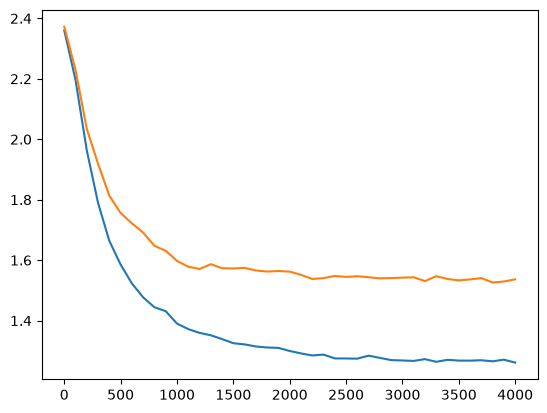

In [140]:
import matplotlib.pyplot as plt

optimizer = optim.AdamW(m.parameters(), lr=3e-5)
losses = training_loop(m, optimizer, INPUT_TRAIN, 1000, 256, 64)
total_steps = 100*len(stats_losses)
print(f"test={losses[1]:.4f} train={losses[0]:.4f}  after  [{total_steps:,}] steps" )

# to beat: 1.8272 
# new best: 1.7573! @ 16.5k steps with ~23 it/s
# test=1.6534 train=1.4576  after  [22,100] steps

# test=1.5807 train=1.3858  after  [2,600] steps
# test=1.5613 train=1.2640  after  [5,100] steps

#test=1.5174 train=1.3056  after  [8,200] steps
#test=1.5140 train=1.2670  after  [16,200] steps

cpu_stats_losses = [(x[0].to("cpu"), x[1].to("cpu")) for x in stats_losses]
plt.plot([x*100 for x in range(len(cpu_stats_losses))], [y[0] for y in cpu_stats_losses])
plt.plot([x*100 for x in range(len(cpu_stats_losses))], [y[1] for y in cpu_stats_losses])

In [134]:
CONTEXT_WIDTH = 64

def generate(context, max_new_tokens):
        for _ in range(max_new_tokens):
            probs = m(context[...,-CONTEXT_WIDTH:])[0,-1]
            next = torch.multinomial(probs, num_samples=1)
            nexti = torch.tensor([[next,],], device=DEVICE)
            context = torch.cat((context, torch.tensor([[next,],], device=DEVICE)), dim=1)
        return context


print(''.join([VOCAB[i] for i in generate(torch.zeros((1, CONTEXT_WIDTH), dtype=torch.long, device=DEVICE), 2000)[0][CONTEXT_WIDTH:].tolist()]))


DUMMasthachUSTON.


CARISLIO:
I thank'st a heart.

GLOUCESTER:

KOMVOND OF AUMERLEa Englad:
I will I not instructed cloth for the runn's
Shadom confederated: and a pawct
And crown's the bowling obtal severy's royal
Abathor at any expect deep?

SICHMONIUS:
O, if they
Not say it. Since he I comes, let me murder myself,
Than he being needful enrage; but I
folly kindness thee to fear: but, you calle,
Live him now, whilst usabel reignor town,
And that you call on the most premise;
Thry with thy former's hunting floods for thee
Which madner.

WARWICK:
'Tis wissing you my lady?

LADY GAUNT:
The Earl of Romeo, 'tis upon thy I see
Either about in thine eye watch of pysmeritable,
Than sweet in sound-tronge.

BRUTUS:
Then were our conqueror'd so say a cousin's,
And blow 'from them the suitor is nor enembrace, great him.
The cause at the poison and that there in
is both some folly priteous, the wantoness up.

GLOUCESTER:
Alaments mend, in one that finds thou art,
Thanks thinkly untimes to me, I ha

# Parameters: 808,257
#test=1.5140 train=1.2670  after  [16,200] steps

m = Transformer3(
    context_width = 64, 
    vocab_size = len(VOCAB), 
    embedding_size = 64,
    num_of_heads = 8,
    num_attention_blocks = 16,
    dropout=0.1).to(DEVICE)

'''
CARISLIO:
I thank'st a heart.

GLOUCESTER:

KOMVOND OF AUMERLEa Englad:
I will I not instructed cloth for the runn's
Shadom confederated: and a pawct
And crown's the bowling obtal severy's royal
Abathor at any expect deep?

SICHMONIUS:
O, if they
Not say it. Since he I comes, let me murder myself,
Than he being needful enrage; but I
folly kindness thee to fear: but, you calle,
Live him now, whilst usabel reignor town,
And that you call on the most premise;
Thry with thy former's hunting floods for thee
Which madner.

WARWICK:
...
ISABELLA:
There is a fraughting spurch'd and day.
'''